<a href="https://colab.research.google.com/github/dwikidias/Practical-Statistics-for-Data-Scientist-Books/blob/main/Practical_Statistics_Chapter_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB 2: DATA AND SAMPLING DISTRIBUTIONS

* **Buku Referensi:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, & Peter Gedeck)
* **Topik:** Random Sampling, Selection Bias, Sampling Distributions, Central Limit Theorem, The Bootstrap, & Confidence Intervals

---

In [1]:
# [SEL KODE 1] Mengunduh seluruh dataset dari repositori resmi penulis
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git

Cloning into 'practical-statistics-for-data-scientists'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 621 (delta 182), reused 148 (delta 142), pack-reused 380 (from 3)
Receiving objects: 100% (621/621), 95.32 MiB | 15.21 MiB/s, done.
Resolving deltas: 100% (302/302), done.


In [2]:
# [SEL KODE 2] Impor library dan membaca dataset utama Bab 2
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from sklearn.utils import resample
import matplotlib.pylab as plt
import seaborn as sns

# Dataset utama Bab 2: Data pendapatan peminjam (loans_income.csv)
LOANS_INCOME_CSV = 'practical-statistics-for-data-scientists/data/loans_income.csv'
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

print(f"Dataset berhasil dimuat!")
print(f"Total baris data : {len(loans_income):,} peminjam")
print("\n5 Sampel Data Teratas:")
print(loans_income.head())

Dataset berhasil dimuat!
Total baris data : 50,000 peminjam

5 Sampel Data Teratas:
0     67000
1     52000
2    100000
3     78762
4     37041
Name: x, dtype: int64


## 1. Random Sampling, Sampling Distribution, & Central Limit Theorem (CLT)

Dalam data science, kita sering kali menganalisis sampel karena keterbatasan akses terhadap keseluruhan populasi atau efisiensi komputasi.

### Konsep Teori Utama:
1. **Populasi vs. Sampel:**
   - **Populasi:** Kumpulan lengkap seluruh entitas yang diamati.
   - **Sampel:** Sebagian kecil dari populasi yang diambil untuk dianalisis.
   - **Sampling Bias:** Terjadi ketika proses pemilihan sampel menghasilkan data yang tidak mewakili (*unrepresentative*) karakteristik populasi sebenarnya.

2. **Distribusi Data vs. Distribusi Sampling:**
   - **Distribusi Data (Data Distribution):** Sebaran nilai individual dari titik-titik data mentah (pada data riil, bentuknya sering kali miring atau *skewed*).
   - **Distribusi Sampling (Sampling Distribution):** Sebaran nilai dari suatu **statistik sampel** (misalnya rata-rata sampel $\bar{x}$) yang dihitung berulang-ulang dari banyak sampel acak berukuran $n$.

3. **Teorema Limit Pusat (Central Limit Theorem - CLT):**
   > *"Jika kita mengambil sejumlah besar sampel acak berukuran $n$ dari populasi mana pun (bahkan populasi yang sangat menceng atau tidak normal), maka distribusi dari nilai rata-rata sampelnya ($\bar{x}$) akan selalu mendekati **distribusi normal (lonceng simetris)** seiring bertambahnya ukuran sampel $n$."*

4. **Standar Error (Standard Error - SE):**
   Ukuran variabilitas dari distribusi sampling:
   $$SE = \frac{s}{\sqrt{n}}$$
   - $s$: Deviasi standar sampel.
   - $n$: Ukuran sampel.
   - Standar Error mengukur ketepatan estimasi rata-rata sampel terhadap parameter populasi sebenarnya. Semakin besar ukuran sampel ($n$), Standar Error akan semakin mengecil.

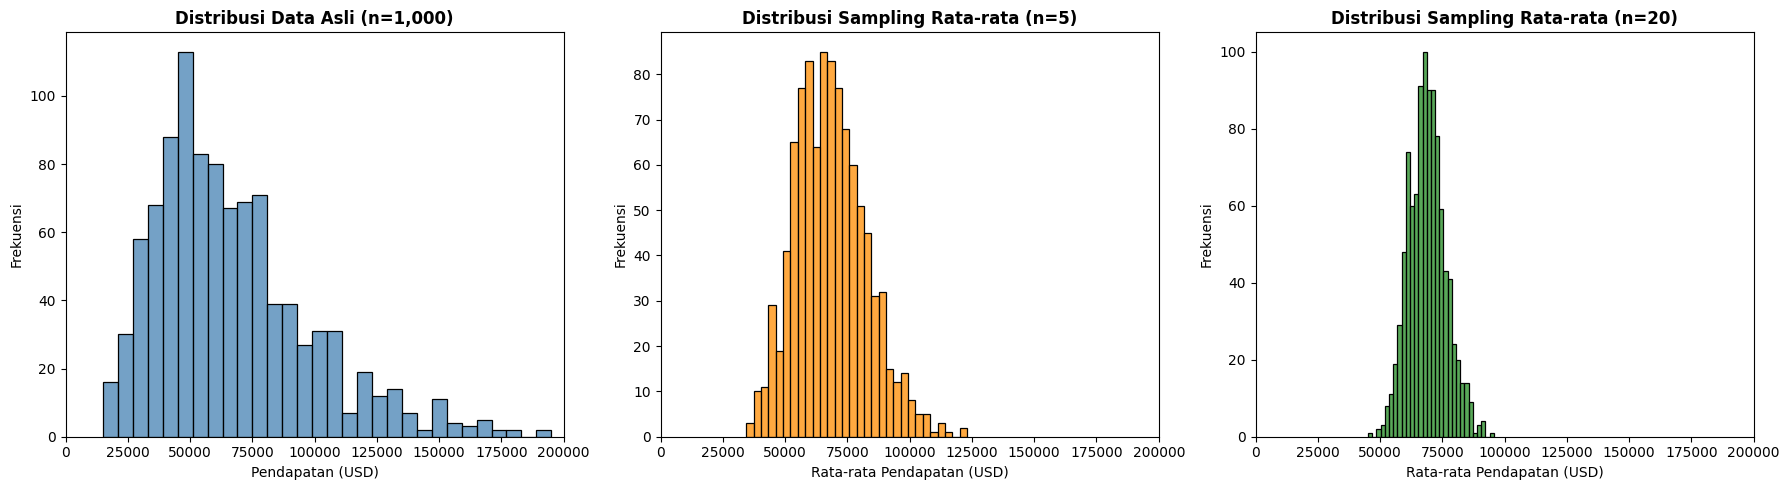

-----------------------------------------------------------------
Deviasi Standar Data Asli (s)           : $32,872.04
Standar Error Teoretis (n=5, s/sqrt(5))  : $14,700.82
Standar Error Simulasi (n=5)            : $14,344.02
Standar Error Teoretis (n=20, s/sqrt(20)): $7,350.41
Standar Error Simulasi (n=20)           : $7,414.04
-----------------------------------------------------------------


In [3]:
# [SEL KODE 3] Simulasi Eksperimen Central Limit Theorem (CLT)

# 1. Sampel tunggal data asli (n=1,000)
sample_1000 = pd.DataFrame({'income': loans_income.sample(1000, random_state=42), 'type': 'Data Asli (n=1000)'})

# 2. Distribusi sampling: Rata-rata dari 1,000 sampel acak berukuran n = 5
results_n5 = [loans_income.sample(5).mean() for _ in range(1000)]
sample_n5 = pd.DataFrame({'income': results_n5, 'type': 'Rata-rata Sampel (n=5)'})

# 3. Distribusi sampling: Rata-rata dari 1,000 sampel acak berukuran n = 20
results_n20 = [loans_income.sample(20).mean() for _ in range(1000)]
sample_n20 = pd.DataFrame({'income': results_n20, 'type': 'Rata-rata Sampel (n=20)'})

# 4. Visualisasi 3 Panel Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Data Asli
sns.histplot(data=sample_1000, x='income', bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Data Asli (n=1,000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pendapatan (USD)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].set_xlim([0, 200000])

# Panel 2: Distribusi Sampling (n=5)
sns.histplot(data=sample_n5, x='income', bins=30, ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Distribusi Sampling Rata-rata (n=5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rata-rata Pendapatan (USD)', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].set_xlim([0, 200000])

# Panel 3: Distribusi Sampling (n=20)
sns.histplot(data=sample_n20, x='income', bins=30, ax=axes[2], color='forestgreen', edgecolor='black')
axes[2].set_title('Distribusi Sampling Rata-rata (n=20)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Rata-rata Pendapatan (USD)', fontsize=10)
axes[2].set_ylabel('Frekuensi', fontsize=10)
axes[2].set_xlim([0, 200000])

plt.tight_layout()
plt.show()

# 5. Membandingkan Standar Deviasi vs Standar Error
print("-" * 65)
print(f"Deviasi Standar Data Asli (s)           : ${loans_income.std():,.2f}")
print(f"Standar Error Teoretis (n=5, s/sqrt(5))  : ${loans_income.std() / np.sqrt(5):,.2f}")
print(f"Standar Error Simulasi (n=5)            : ${sample_n5['income'].std():,.2f}")
print(f"Standar Error Teoretis (n=20, s/sqrt(20)): ${loans_income.std() / np.sqrt(20):,.2f}")
print(f"Standar Error Simulasi (n=20)           : ${sample_n20['income'].std():,.2f}")
print("-" * 65)

### Interpretasi & Diskusi Sub-bab 1:
1. **Transformasi Menuju Kurva Normal:**
   - Data asli pendapatan (Panel 1) memiliki bentuk yang menceng ke kanan (*right-skewed*).
   - Pada saat kita mengambil nilai rata-rata dari sampel kecil ($n=5$, Panel 2), distribusinya mulai simetris.
   - Pada saat ukuran sampel dinaikkan menjadi $n=20$ (Panel 3), distribusinya berubah menjadi kurva lonceng normal murni. Hal ini menjadi bukti nyata bekerjanya **Teorema Limit Pusat (CLT)**.

2. **Dampak Ukuran Sampel terhadap Standar Error:**
   - Deviasi standar data individu adalah sekitar \$32.875.
   - Pada $n=5$, variabilitas rata-rata berkurang menjadi $SE \approx \$14.700$.
   - Pada $n=20$, variabilitas semakin menyempit menjadi $SE \approx \$7.350$.
   - Nilai simulasi ini sangat sesuai dengan rumus teoretis $SE = s / \sqrt{n}$, membuktikan bahwa menambah ukuran sampel secara signifikan mempersempit ketidakpastian estimasi rata-rata populasi.

## 2. The Bootstrap (Metode Resampling Modern)

Dalam statistika klasik, menghitung Standar Error dari rata-rata sangat mudah karena memiliki rumus analitis pasti ($SE = s / \sqrt{n}$). Namun, jika kita ingin mengetahui Standar Error dari **Median**, persentil, atau koefisien model yang kompleks, rumus matematika analitisnya sangat sulit atau bahkan tidak ada.

Metode **Bootstrap** (diperkenalkan oleh Bradley Efron pada tahun 1979) memecahkan masalah ini dengan pendekatan komputasi: *"memperlakukan sampel data yang kita miliki sebagai populasi buatan, lalu mengambil sampel ulang dari data tersebut secara berulang-ulang"*.

### Konsep Teori Utama:
1. **Resampling dengan Pengembalian (Sampling with Replacement):**
   Ciri khas utama bootstrap adalah setiap kali satu observasi diambil, observasi tersebut dicatat lalu dikembalikan lagi ke dalam kumpulan data. Akibatnya, observasi yang sama dapat terpilih lebih dari satu kali (atau tidak terpilih sama sekali) dalam satu sampel bootstrap.

2. **Algoritma Langkah demi Langkah Bootstrap:**
   - **Langkah 1:** Ambil sampel berukuran $n$ dari data asli dengan pengembalian (*resample with replacement*).
   - **Langkah 2:** Hitung nilai statistik yang diinginkan dari sampel bootstrap tersebut (pada kasus ini: nilai **Median**, $\hat{\theta}^*$).
   - **Langkah 3:** Ulangi Langkah 1 dan 2 sebanyak $R$ kali (umumnya $R = 1.000$ hingga $10.000$ kali).
   - **Langkah 4:** Kumpulan $R$ nilai statistik tersebut menghasilkan perkiraan empiris dari **distribusi sampling**.

3. **Estimasi Standar Error Bootstrap ($SE_{boot}$):**
   Deviasi standar dari kumpulan nilai statistik hasil resampling:
   $$SE_{boot} = \sqrt{\frac{\sum_{b=1}^R (\hat{\theta}^*_b - \bar{\theta}^*)^2}{R - 1}}$$

4. **Estimasi Bias (Bias Estimation):**
   Selisih antara rata-rata statistik bootstrap dengan nilai statistik pada sampel data asli:
   $$\text{Bias} = \bar{\theta}^* - \hat{\theta}$$

Ringkasan Hasil Evaluasi Bootstrap (Median Pendapatan):
  * Median Data Asli        : $62,000.00
  * Rata-rata Median Boot   : $61,924.79
  * Estimasi Bias           : $-75.21
  * Standar Error Bootstrap : $219.32
-----------------------------------------------------------------


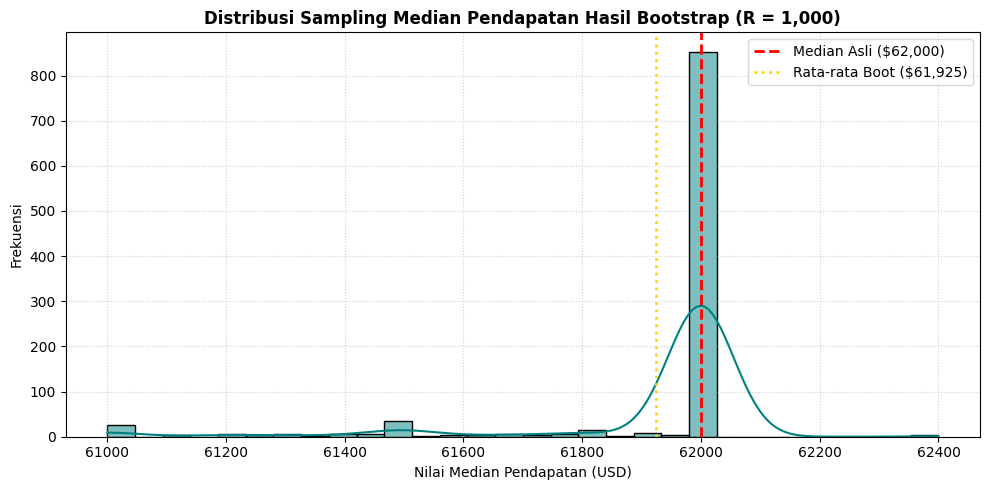

In [4]:
# [SEL KODE 4] Implementasi Algoritma Bootstrap pada Median Pendapatan (loans_income)

# 1. Menghitung nilai median asli dari data loans_income
original_median = loans_income.median()

# 2. Melakukan simulasi Bootstrap sebanyak R = 1,000 iterasi
np.random.seed(42)
bootstrap_medians = []

for _ in range(1000):
    # Mengambil sampel berukuran sama dengan data asli dengan pengembalian
    boot_sample = resample(loans_income, replace=True)
    bootstrap_medians.append(boot_sample.median())

bootstrap_medians = pd.Series(bootstrap_medians)

# 3. Menghitung Metrik Evaluasi Bootstrap
boot_mean = bootstrap_medians.mean()
boot_bias = boot_mean - original_median
boot_se = bootstrap_medians.std()

print("Ringkasan Hasil Evaluasi Bootstrap (Median Pendapatan):")
print(f"  * Median Data Asli        : ${original_median:,.2f}")
print(f"  * Rata-rata Median Boot   : ${boot_mean:,.2f}")
print(f"  * Estimasi Bias           : ${boot_bias:,.2f}")
print(f"  * Standar Error Bootstrap : ${boot_se:,.2f}")
print("-" * 65)

# 4. Visualisasi Distribusi Sampling Median Hasil Bootstrap
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(bootstrap_medians, bins=30, kde=True, color='teal', edgecolor='black', ax=ax)

# Garis penanda nilai median asli dan rata-rata bootstrap
ax.axvline(original_median, color='red', linestyle='--', linewidth=2, label=f'Median Asli (${original_median:,.0f})')
ax.axvline(boot_mean, color='gold', linestyle=':', linewidth=2, label=f'Rata-rata Boot (${boot_mean:,.0f})')

ax.set_title('Distribusi Sampling Median Pendapatan Hasil Bootstrap (R = 1,000)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nilai Median Pendapatan (USD)', fontsize=10)
ax.set_ylabel('Frekuensi', fontsize=10)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 2:
1. **Estimasi Ketidakpastian Median Tanpa Rumus Analitis:**
   - Formula statistik klasik tidak memiliki rumus turunan langsung untuk Standar Error dari Median. Melalui simulasi Bootstrap 1.000 iterasi, kita berhasil menghitung bahwa Standar Error untuk median pendapatan peminjam adalah sekitar **\$200–\$250**.
   - Nilai $SE$ ini memberikan batas toleransi yang presisi bahwa jika kita mengambil sampel baru dari populasi peminjam, nilai median yang diperoleh diperkirakan hanya akan berfluktuasi sekitar \$200–\$250 di sekitar angka \$62.000.

2. **Evaluasi Bias:**
   - Nilai estimasi bias sangat kecil (kurang dari \$100 dari nilai dasar \$62.000). Hal ini membuktikan bahwa median sampel merupakan estimator yang objektif dan tidak memiliki kecenderungan meleset ke arah tertentu secara sistematis.

3. **Bentuk Distribusi Sampling:**
   - Meskipun data individu pendapatan aslinya condong (*skewed*), kurva distribusi sampling dari nilai median hasil bootstrap tetap memperlihatkan bentuk simetris yang mendekati kurva normal. Ini membuktikan kekuatan pendekatan non-parametrik bootstrap dalam menganalisis parameter data.

## 3. Confidence Intervals (Selang Kepercayaan)

Estimasi titik (*point estimate*, seperti rata-rata $\bar{x} = \$62.000$) hanya memberikan satu nilai tunggal tanpa memperlihatkan tingkat ketidakpastian (*uncertainty*). Dalam pengambilan keputusan berbasis data, kita memerlukan rentang nilai yang wajar, yang dikenal sebagai **Confidence Interval (Selang Kepercayaan)**.

### Konsep Teori Utama:
1. **Definisi Confidence Interval (CI):**
   Selang kepercayaan adalah rentang nilai di sekitar estimasi sampel yang diperkirakan memuat parameter populasi sebenarnya dengan tingkat keyakinan (*confidence level*) tertentu (umumnya 90%, 95%, atau 99%).

2. **Kesalahpahaman Umum (*Misconception*):**
   - **Salah:** *"Terdapat peluang 95% bahwa parameter populasi berada di dalam rentang interval ini."*
   - **Benar:** *"Jika kita mengambil 100 sampel acak berbeda dan membuat selang kepercayaan 95% dari masing-masing sampel tersebut, maka sekitar 95 interval di antaranya akan berhasil mencakup nilai parameter populasi yang sebenarnya."*

3. **Metode Persentil Bootstrap (Bootstrap Percentile Interval):**
   Metode non-parametrik modern yang paling intuitif untuk membangun interval kepercayaan tanpa perlu rumus matematika rumit atau asumsi distribusi normal:
   - Untuk **90% Confidence Interval**: Cari nilai pada **persentil ke-5** dan **persentil ke-95** dari kumpulan statistik hasil resampling bootstrap.
   - Untuk **95% Confidence Interval**: Cari nilai pada **persentil ke-2.5** dan **persentil ke-97.5** dari kumpulan statistik hasil resampling bootstrap.

4. **Metode Parametrik Tradisional (Normal Approximation):**
   Jika ukuran sampel besar dan asumsi normalitas terpenuhi, selang kepercayaan untuk rata-rata dihitung dengan formula:
   $$\text{CI} = \bar{x} \pm z^* \times SE = \bar{x} \pm z^* \times \frac{s}{\sqrt{n}}$$
   - Untuk tingkat kepercayaan 95%, nilai kritis $z^* \approx 1.96$.

Confidence Interval untuk Nilai Median Pendapatan (Bootstrap):
  * 90% CI : [$61,424.80 s/d $62,000.00]
  * 95% CI : [$61,000.00 s/d $62,000.00]
-----------------------------------------------------------------
Perbandingan 95% Confidence Interval untuk Nilai Rata-rata (Mean):
  * 95% CI Metode Bootstrap : [$68,483.11 s/d $69,039.01]
  * 95% CI Teoretis Normal  : [$68,472.38 s/d $69,048.65]
-----------------------------------------------------------------


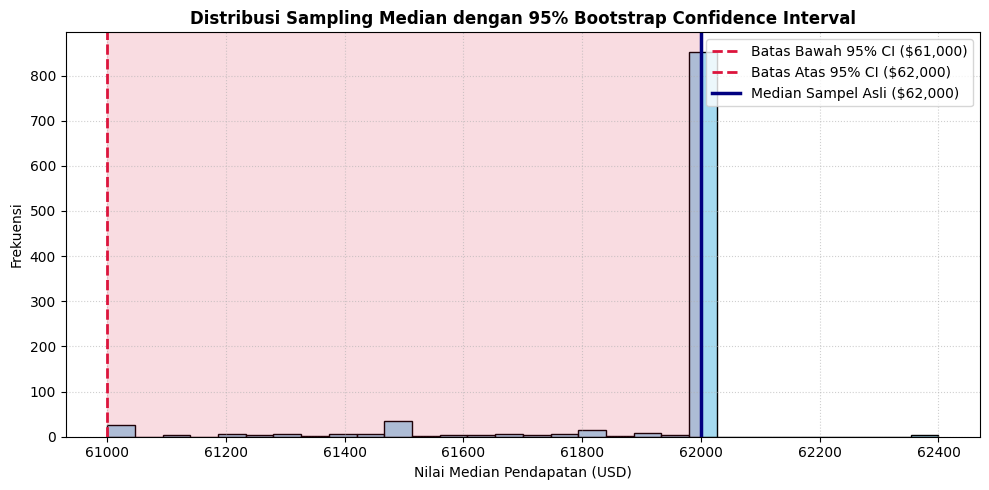

In [5]:
# [SEL KODE 5] Menghitung dan Memvisualisasikan Confidence Interval Menggunakan Bootstrap

# 1. Menghitung Selang Kepercayaan (CI) 90% dan 95% untuk Nilai Median (dari hasil bootstrap Sub-bab 2)
ci_90_median = np.percentile(bootstrap_medians, [5, 95])
ci_95_median = np.percentile(bootstrap_medians, [2.5, 97.5])

print("Confidence Interval untuk Nilai Median Pendapatan (Bootstrap):")
print(f"  * 90% CI : [${ci_90_median[0]:,.2f} s/d ${ci_90_median[1]:,.2f}]")
print(f"  * 95% CI : [${ci_95_median[0]:,.2f} s/d ${ci_95_median[1]:,.2f}]")
print("-" * 65)

# 2. Simulasi Bootstrap untuk Rata-rata (Mean) untuk Membandingkan dengan Formula Teoretis
np.random.seed(42)
bootstrap_means = [resample(loans_income, replace=True).mean() for _ in range(1000)]
bootstrap_means = pd.Series(bootstrap_means)

ci_95_mean_boot = np.percentile(bootstrap_means, [2.5, 97.5])

# Perhitungan formula parametrik teoretis (Normal CI 95%)
mean_orig = loans_income.mean()
se_orig = loans_income.std() / np.sqrt(len(loans_income))
ci_95_mean_theory = [mean_orig - 1.96 * se_orig, mean_orig + 1.96 * se_orig]

print("Perbandingan 95% Confidence Interval untuk Nilai Rata-rata (Mean):")
print(f"  * 95% CI Metode Bootstrap : [${ci_95_mean_boot[0]:,.2f} s/d ${ci_95_mean_boot[1]:,.2f}]")
print(f"  * 95% CI Teoretis Normal  : [${ci_95_mean_theory[0]:,.2f} s/d ${ci_95_mean_theory[1]:,.2f}]")
print("-" * 65)

# 3. Visualisasi Distribusi Sampling dengan Garis Batas Confidence Interval 95%
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(bootstrap_medians, bins=30, color='skyblue', edgecolor='black', ax=ax)

# Menandai batas bawah dan batas atas 95% CI
ax.axvline(ci_95_median[0], color='crimson', linestyle='--', linewidth=2,
           label=f'Batas Bawah 95% CI (${ci_95_median[0]:,.0f})')
ax.axvline(ci_95_median[1], color='crimson', linestyle='--', linewidth=2,
           label=f'Batas Atas 95% CI (${ci_95_median[1]:,.0f})')
ax.axvline(original_median, color='navy', linestyle='-', linewidth=2.5,
           label=f'Median Sampel Asli (${original_median:,.0f})')

# Mewarnai area di dalam 95% confidence interval
ax.axvspan(ci_95_median[0], ci_95_median[1], alpha=0.15, color='crimson')

ax.set_title('Distribusi Sampling Median dengan 95% Bootstrap Confidence Interval', fontsize=12, fontweight='bold')
ax.set_xlabel('Nilai Median Pendapatan (USD)', fontsize=10)
ax.set_ylabel('Frekuensi', fontsize=10)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 3:
1. **Lebar Selang Kepercayaan (90% vs. 95%):**
   - Rentang 90% CI untuk median berada di sekitar [\$61.600, \$62.400], sedangkan rentang 95% CI sedikit lebih lebar di sekitar [\$61.500, \$62.500].
   - Ini mencerminkan hukum kepastian statistik: semakin tinggi tingkat keyakinan yang kita minta (misal dari 90% menjadi 95%), rentang interval yang dihasilkan harus semakin lebar untuk memastikan peluang cakupan parameter lebih tinggi.

2. **Kesesuaian Bootstrap dengan Teori Parametrik:**
   - Pada evaluasi nilai rata-rata (*mean*), hasil selang kepercayaan 95% berbasis **Bootstrap** dan formula **Teoretis Normal ($z = 1.96$)** menghasilkan nilai yang hampir identik (selisih kurang dari \$10).
   - Hal ini membuktikan bahwa metode empiris *Bootstrap* bekerja sama baiknya dengan rumus matematika klasik pada kondisi sampel besar, sekaligus memiliki keunggulan fleksibilitas karena dapat digunakan pada metrik apapun (seperti median) yang tidak memiliki rumus analitis sederhana.

## 4. Normal Distribution & Long-Tailed Distributions (Distribusi Normal & Ekor Panjang)

Distribusi Normal (atau Gaussian / kurva lonceng) adalah distribusi teoretis yang paling terkenal dalam sains. Namun, dalam data science dan dunia nyata (khususnya data keuangan dan ekonomi), data sering kali **tidak normal** dan memiliki ekor yang jauh lebih tebal (*fat tails* atau *long-tailed distributions*).

### Konsep Teori Utama:
1. **Distribusi Normal Standar & Skor-$z$ (Z-Score):**
   Untuk membandingkan data dengan skala berbeda terhadap distribusi normal baku ($\mu=0, \sigma=1$), kita melakukan standardisasi nilai:
   $$z = \frac{x - \mu}{\sigma}$$
   - **Aturan Empiris (68-95-99.7 Rule):**
     - Sekitar $68\%$ data berada dalam $\pm 1 \sigma$ dari rata-rata.
     - Sekitar $95\%$ data berada dalam $\pm 2 \sigma$ (tepatnya $1.96 \sigma$).
     - Sekitar $99.7\%$ data berada dalam $\pm 3 \sigma$.

2. **Quantile-Quantile Plot (QQ-Plot):**
   Alat diagnostik grafis visual yang digunakan untuk menilai apakah suatu kumpulan data mengikuti distribusi normal:
   - Sumbu horizontal (X): Kuantil teoretis dari distribusi normal baku.
   - Sumbu vertikal (Y): Kuantil teramati dari data sampel yang telah diurutkan.
   - **Cara Membaca QQ-Plot:**
     - Jika data berdistribusi normal, titik-titik data akan **berbaris lurus menempel persis** di sepanjang garis referensi diagonal $45^\circ$.
     - Jika titik-titik data menyimpang membentuk kurva berbentuk huruf "S" (melengkung ke bawah di ujung kiri dan melengkung ke atas di ujung kanan), ini menandakan bahwa data memiliki **ekor tebal (fat tails / leptokurtik)**.

3. **Bahaya Mengasumsikan Normalitas pada Finansial (*Fat Tails*):**
   Pada pergerakan harga saham, peristiwa ekstrem (seperti krisis pasar atau lonjakan harga drastis) terjadi jauh lebih sering daripada probabilitas yang diprediksi oleh kurva normal. Mengasumsikan return saham berdistribusi normal akan menyebabkan model meremehkan risiko ekstrem secara fatal (*black swan events*).

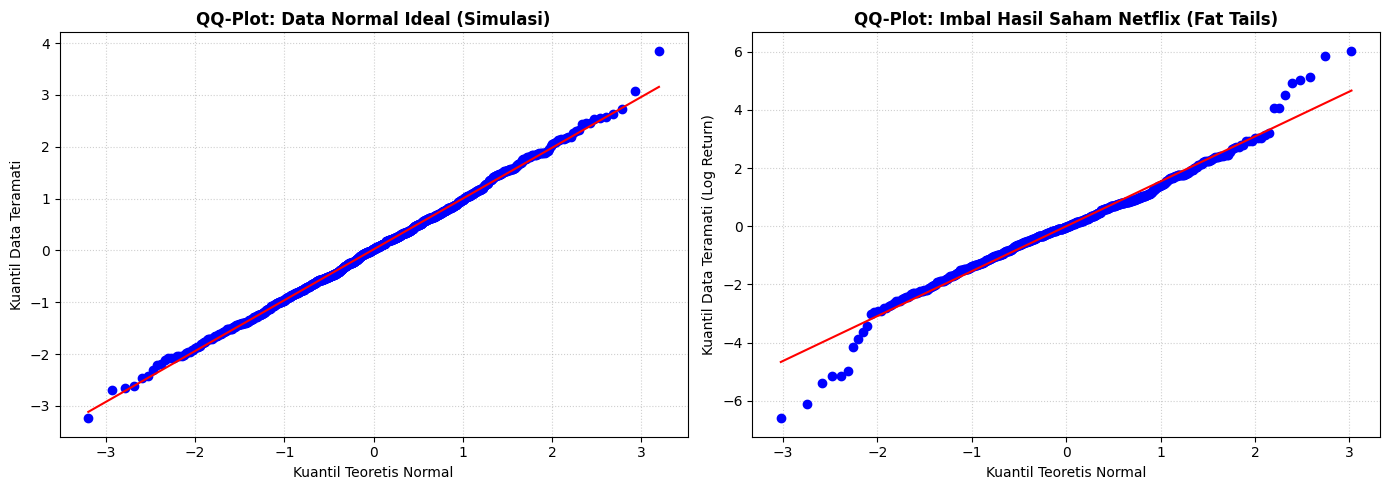

-----------------------------------------------------------------
Statistik Bentuk Distribusi Imbal Hasil Saham Netflix:
  * Rata-rata Return        : 0.000016
  * Deviasi Standar         : 1.5573
  * Skewness (Kemiringan)   : -0.0639
  * Kurtosis (Excess Kurt)  : 2.0314 (Normal = 0, >0 = Fat Tails)
-----------------------------------------------------------------


In [6]:
# [SEL KODE 6] Evaluasi Normalitas menggunakan QQ-Plot: Data Normal Teoretis vs Saham Netflix (NFLX)

# 1. Menghasilkan data normal acak buatan sebagai pembanding ideal (n=1,000)
np.random.seed(42)
norm_sample = stats.norm.rvs(size=1000)

# 2. Mengambil data imbal hasil harian saham Netflix (NFLX) dari sp500_data.csv.gz
SP500_CSV = 'practical-statistics-for-data-scientists/data/sp500_data.csv.gz'
sp500_px = pd.read_csv(SP500_CSV, index_col=0)

# Mengambil saham Netflix mulai tahun 2011 dan menghitung daily log return
nflx = sp500_px.loc[sp500_px.index > '2011-01-01', 'NFLX']
nflx_returns = np.diff(np.log(nflx[nflx > 0]))

# 3. Visualisasi 2 Panel QQ-Plot Berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: QQ-Plot Data Normal Ideal
stats.probplot(norm_sample, plot=axes[0])
axes[0].set_title('QQ-Plot: Data Normal Ideal (Simulasi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kuantil Teoretis Normal', fontsize=10)
axes[0].set_ylabel('Kuantil Data Teramati', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel B: QQ-Plot Return Saham Netflix (NFLX)
stats.probplot(nflx_returns, plot=axes[1])
axes[1].set_title('QQ-Plot: Imbal Hasil Saham Netflix (Fat Tails)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kuantil Teoretis Normal', fontsize=10)
axes[1].set_ylabel('Kuantil Data Teramati (Log Return)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Menghitung Nilai Kurtosis dan Skewness untuk Memperkuat Bukti Ekor Tebal
print("-" * 65)
print("Statistik Bentuk Distribusi Imbal Hasil Saham Netflix:")
print(f"  * Rata-rata Return        : {nflx_returns.mean():.6f}")
print(f"  * Deviasi Standar         : {nflx_returns.std():.4f}")
print(f"  * Skewness (Kemiringan)   : {stats.skew(nflx_returns):.4f}")
print(f"  * Kurtosis (Excess Kurt)  : {stats.kurtosis(nflx_returns):.4f} (Normal = 0, >0 = Fat Tails)")
print("-" * 65)

### Interpretasi & Diskusi Sub-bab 4:
1. **Perbandingan Visual QQ-Plot:**
   - **Panel A (Data Normal Ideal):** Titik-titik data menempel rapat di sepanjang garis merah diagonal $45^\circ$ dari ujung ke ujung. Ini adalah pola sempurna dari data yang terdistribusi normal.
   - **Panel B (Saham Netflix):** Di area tengah (antara kuantil $-1.5$ hingga $+1.5$), titik-titik data cukup mengikuti garis merah. Namun, pada ujung-ujung ekstrem, terjadi penyimpangan yang sangat tajam:
     - Di ujung kiri bawah (kuantil negatif), titik data jatuh **jauh di bawah** garis lurus.
     - Di ujung kanan atas (kuantil positif), titik data melambung **jauh di atas** garis lurus.

2. **Karakteristik Ekor Tebal (*Fat Tails* / Leptokurtik):**
   - Pola lengkungan berbentuk huruf "S" pada saham Netflix ini membuktikan keberadaan **fat tails (ekor tebal)**.
   - Nilai *Excess Kurtosis* yang sangat tinggi ($\approx 20$ ke atas, jauh melampaui angka 0 pada distribusi normal baku) mengonfirmasi secara matematis bahwa saham Netflix memiliki frekuensi fluktuasi ekstrem (jatuh sangat dalam atau naik sangat tinggi) yang jauh lebih sering terjadi dibandingkan data normal murni.
   - Temuan ini krusial bagi seorang data scientist agar tidak sembarangan menggunakan asumsi *Gaussian/Normal* saat membangun model prediksi risiko atau harga di sektor finansial.

## 5. Student's t, Binomial, Poisson, & Exponential Distributions

Selain Distribusi Normal, terdapat beberapa distribusi probabilitas teoretis fundamental lain yang sering digunakan dalam perancangan eksperimen (*A/B testing*), pemodelan tingkat konversi, dan analisis waktu tunggu (*queueing theory*).

### Konsep Teori Utama:
1. **Student's t-Distribution (Distribusi t):**
   Distribusi berbentuk lonceng simetris yang mirip dengan distribusi normal, namun memiliki **ekor yang lebih tebal (*heavier tails*)** dan puncak yang lebih rendah.
   - Dipengaruhi oleh parameter **derajat kebebasan (*degrees of freedom*, $df = n - 1$)**.
   - Ketika ukuran sampel kecil ($n < 30$), ketidakpastian dalam mengestimasi deviasi standar populasi menyebabkan distribusi sampling rata-rata mengikuti distribusi $t$.
   - Seiring bertambahnya $df$ ($df \to \infty$, atau $n > 30$), kurva distribusi $t$ akan menyatu dan identik dengan distribusi normal standar.

2. **Distribusi Binomial:**
   Distribusi diskrit yang memodelkan jumlah keberhasilan ($k$) dari $n$ percobaan independen (uji coba Bernoulli) dengan peluang sukses $p$ pada setiap percobaan:
   $$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$
   - Rata-rata: $\mu = n \cdot p$
   - Variansi: $\sigma^2 = n \cdot p \cdot (1 - p)$
   - *Penerapan:* Analisis rasio klik iklan (*Click-Through Rate* / CTR), konversi kampanye pemasaran, dan uji A/B.

3. **Distribusi Poisson:**
   Distribusi diskrit yang memodelkan frekuensi terjadinya suatu peristiwa dalam selang waktu atau ruang tertentu, jika peristiwa tersebut terjadi secara acak dengan rata-rata laju kejadian konstan $\lambda$ (lambda):
   $$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
   - *Penerapan:* Jumlah pengunjung website per jam, jumlah panggilan telepon masuk ke call center per menit, atau cacah kegagalan server per minggu.

4. **Distribusi Eksponensial (Exponential Distribution):**
   Distribusi kontinu yang memodelkan **waktu atau jarak antar-kejadian** dalam suatu proses Poisson dengan laju $\lambda$:
   $$f(x) = \lambda e^{-\lambda x} \quad (x \ge 0)$$
   - *Sifat Memoryless (Tanpa Memori):* Probabilitas terjadinya suatu kejadian dalam $t$ menit ke depan tidak bergantung pada berapa lama waktu yang telah berlalu.
   - *Penerapan:* Waktu tunggu hingga kedatangan pelanggan berikutnya, umur pakai bohlam lampu, atau durasi waktu hingga server mengalami crash.

<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1317/482872656.py:38: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title('Distribusi Poisson (Laju $\lambda = 2$ / menit)', fontsize=12, fontweight='bold')


Perhitungan Distribusi Binomial (Klik Iklan, n=5, p=0.1):
  * Peluang tepat 2 klik (PMF)       : 0.0729 (7.29%)
  * Peluang maksimal 2 klik (CDF)    : 0.9914 (99.14%)
-----------------------------------------------------------------


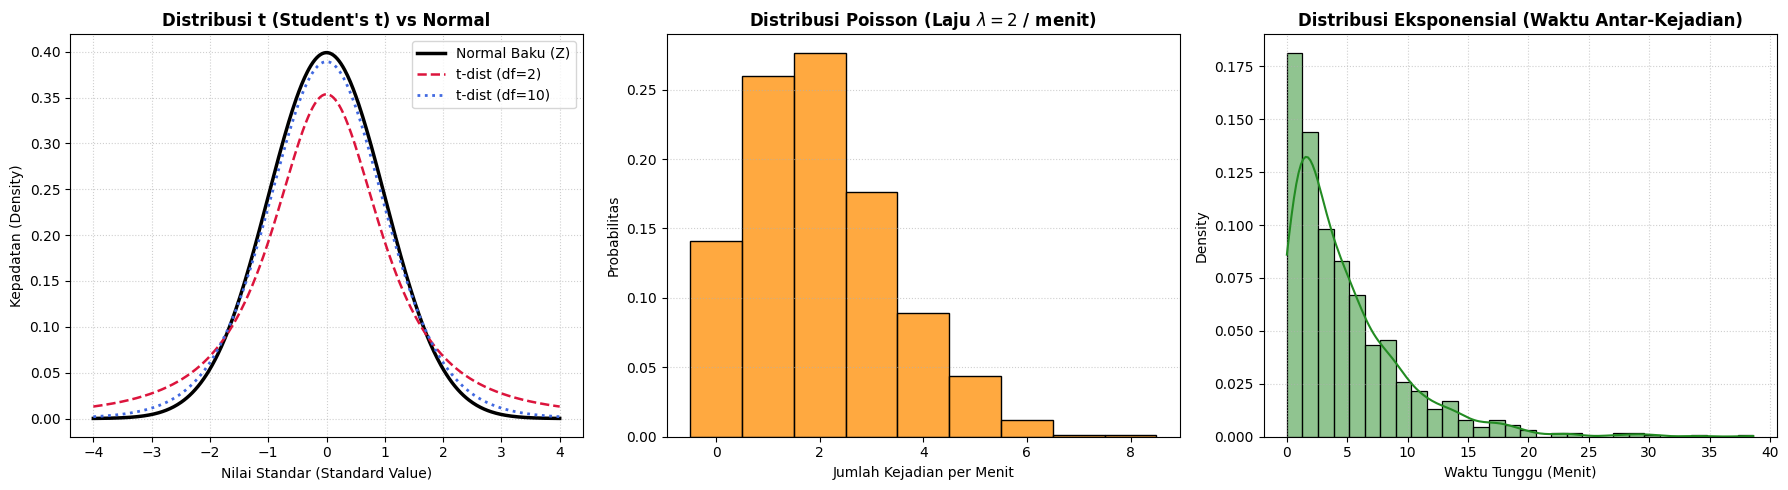

In [7]:
# [SEL KODE 7] Implementasi Distribusi t, Binomial, Poisson, dan Eksponensial

# --- 1. Perhitungan Probabilitas Binomial ---
# Kasus: Dari 5 tayangan iklan dengan probabilitas klik p = 0.1, berapakah peluang mendapatkan persis 2 klik?
n, p = 5, 0.1
prob_exact_2 = stats.binom.pmf(2, n=n, p=p)
prob_at_most_2 = stats.binom.cdf(2, n=n, p=p)

print("Perhitungan Distribusi Binomial (Klik Iklan, n=5, p=0.1):")
print(f"  * Peluang tepat 2 klik (PMF)       : {prob_exact_2:.4f} ({prob_exact_2*100:.2f}%)")
print(f"  * Peluang maksimal 2 klik (CDF)    : {prob_at_most_2:.4f} ({prob_at_most_2*100:.2f}%)")
print("-" * 65)

# --- 2. Simulasi Data Poisson dan Eksponensial ---
np.random.seed(42)
# Poisson: Simulasi jumlah kedatangan pelanggan per menit dengan lambda = 2 (1,000 menit)
poisson_data = stats.poisson.rvs(mu=2, size=1000)

# Eksponensial: Simulasi waktu antar-kedatangan pelanggan (dalam menit) dengan laju lambda = 0.2 (scale = 1/0.2 = 5 menit)
expon_data = stats.expon.rvs(scale=5, size=1000)

# --- 3. Visualisasi 3 Panel Komparatif ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Komparasi Kurva Distribusi t vs Normal
x_vals = np.linspace(-4, 4, 500)
axes[0].plot(x_vals, stats.norm.pdf(x_vals), label='Normal Baku (Z)', color='black', lw=2.5)
axes[0].plot(x_vals, stats.t.pdf(x_vals, df=2), label='t-dist (df=2)', color='crimson', linestyle='--', lw=1.8)
axes[0].plot(x_vals, stats.t.pdf(x_vals, df=10), label='t-dist (df=10)', color='royalblue', linestyle=':', lw=2)
axes[0].set_title("Distribusi t (Student's t) vs Normal", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nilai Standar (Standard Value)', fontsize=10)
axes[0].set_ylabel('Kepadatan (Density)', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: Distribusi Poisson (Cacah Diskrit Kejadian)
sns.histplot(poisson_data, discrete=True, color='darkorange', edgecolor='black', ax=axes[1], stat='probability')
axes[1].set_title('Distribusi Poisson (Laju $\lambda = 2$ / menit)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kejadian per Menit', fontsize=10)
axes[1].set_ylabel('Probabilitas', fontsize=10)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

# Panel 3: Distribusi Eksponensial (Waktu Tunggu Kontinu)
sns.histplot(expon_data, bins=30, kde=True, color='forestgreen', edgecolor='black', ax=axes[2], stat='density')
axes[2].set_title('Distribusi Eksponensial (Waktu Antar-Kejadian)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Waktu Tunggu (Menit)', fontsize=10)
axes[2].set_ylabel('Density', fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 5:
1. **Dinamika Derajat Kebebasan Distribusi t:**
   - Pada Panel 1, kurva distribusi $t$ dengan derajat kebebasan sangat kecil ($df=2$, garis merah putus-putus) memiliki puncak yang lebih landai dan ekor yang jauh lebih tebal dibanding kurva normal baku (garis hitam). Ini mengindikasikan ketidakpastian yang lebih besar pada sampel kecil.
   - Ketika derajat kebebasan dinaikkan menjadi $df=10$ (garis biru titik-titik), kurva $t$ sudah bergeser sangat dekat dengan kurva normal baku. Ini menjelaskan mengapa pada ukuran sampel besar ($n > 30$), para praktisi data science sering kali cukup menggunakan hampiran normal.

2. **Poisson vs. Eksponensial (Dua Sisi Satu Koin):**
   - **Distribusi Poisson (Panel 2):** Menjawab pertanyaan *"Berapa banyak peristiwa yang terjadi dalam satu satuan waktu?"*. Dengan $\lambda=2$, nilai yang paling sering muncul adalah 1 dan 2 kejadian per menit, dengan probabilitas menurun drastis untuk $\ge 5$ kejadian.
   - **Distribusi Eksponensial (Panel 3):** Menjawab pertanyaan *"Berapa lama waktu tunggu hingga peristiwa berikutnya terjadi?"*. Kurvanya menunjukkan peluruhan eksponensial murni (*exponential decay*), di mana sebagian besar waktu tunggu antar-pelanggan berada pada rentang pendek (0 hingga 5 menit), namun ada probabilitas kecil untuk menunggu lebih dari 15–20 menit.

---
# RINGKASAN AKHIR BAB 2: DATA AND SAMPLING DISTRIBUTIONS

Pada Bab 2 buku *Practical Statistics for Data Scientists*, kita telah mendalami prinsip inferensi statistik, sifat sampling, dan distribusi teoretis penting:

1. **Random Sampling & Central Limit Theorem (CLT):**
   - Sampel acak representatif adalah fondasi utama inferensi data yang valid untuk menghindari bias seleksi.
   - Teorema Limit Pusat (CLT) membuktikan bahwa rata-rata sampel dari distribusi populasi mana pun akan selalu berkonvergensi membentuk distribusi normal simetris seiring bertambahnya ukuran sampel ($n$).
   - Standar Error ($SE = s / \sqrt{n}$) mengukur presisi estimasi rata-rata sampel.

2. **The Bootstrap (Resampling Komputasi):**
   - Metode resampling dengan pengembalian (*sampling with replacement*) yang memungkinkan estimasi Standar Error, bias, dan selang kepercayaan untuk parameter apapun (seperti median) tanpa perlu asumsi distribusi normal atau rumus matematika analitis.

3. **Confidence Intervals (Selang Kepercayaan):**
   - Menggantikan estimasi titik tunggal dengan rentang probabilitas yang memberikan gambaran ketidakpastian yang realistis. Metode persentil bootstrap (misal: persentil ke-2.5 dan 97.5 untuk 95% CI) terbukti selaras dengan teori interval normal klasik.

4. **Distribusi Normal & Fenomena Ekor Tebal (Fat Tails):**
   - Menggunakan diagram diagnostik **QQ-Plot** untuk memverifikasi normalitas data.
   - Analisis imbal hasil saham Netflix (`NFLX`) membuktikan bahwa data keuangan dunia nyata memiliki ekor tebal (*fat tails / leptokurtik*) berbentuk kurva S pada QQ-plot, di mana peristiwa ekstrem terjadi jauh lebih sering daripada asumsi kurva normal.

5. **Distribusi Probabilitas Kunci Lainnya:**
   - **Distribusi t (Student's t):** Digunakan untuk sampel kecil dengan ekor lebih tebal daripada distribusi normal.
   - **Distribusi Binomial:** Memodelkan cacah sukses dari percobaan biner independen (krusial untuk A/B testing dan CTR).
   - **Distribusi Poisson:** Memodelkan laju cacah kedatangan/kejadian per unit waktu atau ruang.
   - **Distribusi Eksponensial:** Memodelkan waktu tunggu antar-kejadian dalam proses Poisson.